In [2]:
# IMPORT LIBRARIES
import pandas as pd                 # Library used for working with data sets and perform data analysis.
import numpy as np                  # To perform mathematical operasion and statistics
from datetime import datetime       # Used to perform dates and time manipulation
import seaborn as sns               # To perform data visualization
import matplotlib.pyplot as plt     # To perform data visualization
import re

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore' )

In [3]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Search for files by listing the directory
!ls "/content/drive/MyDrive/Tableau/"   # if the file is located inside this folder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
admissions.csv	branches.csv	 doctors.csv
billing.csv	departments.csv  patients.csv


In [4]:
import pandas as pd

# Lokasi folder yang benar
folder_path = '/content/drive/MyDrive/Tableau/'

# Daftar file CSV
files = [
    'admissions.csv',
    'branches.csv',
    'doctors.csv',
    'billing.csv',
    'departments.csv',
    'patients.csv'
]

# Loop membaca setiap file
for file in files:
    file_path = folder_path + file
    try:
        df = pd.read_csv(file_path)
        rows, cols = df.shape
        print(f"📄 {file}: {rows} baris, {cols} kolom")
    except FileNotFoundError:
        print(f"❌ {file} tidak ditemukan di {folder_path}")
    except Exception as e:
        print(f"⚠️ Gagal membaca {file}: {e}")

📄 admissions.csv: 5000 baris, 12 kolom
📄 branches.csv: 8 baris, 9 kolom
📄 doctors.csv: 64 baris, 7 kolom
📄 billing.csv: 5000 baris, 9 kolom
📄 departments.csv: 8 baris, 3 kolom
📄 patients.csv: 1800 baris, 9 kolom


In [5]:
# ============================================================
# 1. MOUNT GOOGLE DRIVE & BACA SEMUA FILE CSV
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# Lokasi folder (sesuaikan jika berbeda)
folder_path = '/content/drive/MyDrive/Tableau/'

# Nama file sesuai daftar
files = {
    'admissions': 'admissions.csv',
    'branches': 'branches.csv',
    'doctors': 'doctors.csv',
    'billing': 'billing.csv',
    'departments': 'departments.csv',
    'patients': 'patients.csv'
}

# Membaca semua file ke dalam dictionary DataFrames
dataframes = {}
for name, filename in files.items():
    filepath = folder_path + filename
    try:
        df = pd.read_csv(filepath)
        # Konversi kolom tanggal jika ada (asumsi admission_date, discharge_date)
        if 'admission_date' in df.columns:
            df['admission_date'] = pd.to_datetime(df['admission_date'])
        if 'discharge_date' in df.columns:
            df['discharge_date'] = pd.to_datetime(df['discharge_date'])
        dataframes[name] = df
        print(f"✓ {filename}: {df.shape[0]} baris, {df.shape[1]} kolom")
    except FileNotFoundError:
        print(f"✗ File tidak ditemukan: {filepath}")
    except Exception as e:
        print(f"✗ Gagal membaca {filename}: {e}")

# Ekstrak masing-masing DataFrame ke variabel terpisah (agar mudah dipanggil)
admissions = dataframes.get('admissions')
branches = dataframes.get('branches')
doctors = dataframes.get('doctors')
billing = dataframes.get('billing')
departments = dataframes.get('departments')
patients = dataframes.get('patients')

# Pastikan semua data berhasil dimuat
if admissions is None:
    raise Exception("Data admissions tidak ditemukan. Periksa path file.")

print("\n✅ Semua data berhasil dimuat!")
print(f"Data admissions: {admissions.shape}")
print(f"Data branches: {branches.shape}")
print(f"Data doctors: {doctors.shape}")
print(f"Data billing: {billing.shape}")
print(f"Data departments: {departments.shape}")
print(f"Data patients: {patients.shape}")

# ============================================================
# 2. LANJUTKAN DENGAN SEMUA ANALISIS (QUERY YANG SUDAH DIKONVERSI)
# ============================================================
# (Tempelkan seluruh kode analisis dari jawaban sebelumnya di sini)
# Pastikan tidak ada duplikasi definisi variabel. Mulai dari "=== Eksplorasi Data Awal ==="

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ admissions.csv: 5000 baris, 12 kolom
✓ branches.csv: 8 baris, 9 kolom
✓ doctors.csv: 64 baris, 7 kolom
✓ billing.csv: 5000 baris, 9 kolom
✓ departments.csv: 8 baris, 3 kolom
✓ patients.csv: 1800 baris, 9 kolom

✅ Semua data berhasil dimuat!
Data admissions: (5000, 12)
Data branches: (8, 9)
Data doctors: (64, 7)
Data billing: (5000, 9)
Data departments: (8, 3)
Data patients: (1800, 9)


In [6]:
# ============================================================
# HOSPITAL BUSINESS DASHBOARD - ANALISIS LENGKAP DI COLAB
# ============================================================

# 1. Mount Drive dan baca CSV
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

folder_path = '/content/drive/MyDrive/Tableau/'
files = {
    'admissions': 'admissions.csv',
    'branches': 'branches.csv',
    'doctors': 'doctors.csv',
    'billing': 'billing.csv',
    'departments': 'departments.csv',
    'patients': 'patients.csv'
}

dataframes = {}
for name, filename in files.items():
    filepath = folder_path + filename
    df = pd.read_csv(filepath)
    if 'admission_date' in df.columns:
        df['admission_date'] = pd.to_datetime(df['admission_date'])
    if 'discharge_date' in df.columns:
        df['discharge_date'] = pd.to_datetime(df['discharge_date'])
    dataframes[name] = df
    print(f"{filename}: {df.shape[0]} baris, {df.shape[1]} kolom")

admissions = dataframes['admissions']
branches = dataframes['branches']
doctors = dataframes['doctors']
billing = dataframes['billing']
departments = dataframes['departments']
patients = dataframes['patients']

print("\n✅ Data siap digunakan.\n")

# ============================================================
# LANJUTKAN DENGAN SEMUA ANALISIS (tempelkan kode dari jawaban sebelumnya)
# ============================================================

# --- Mulai dari sini adalah kode analisis yang sudah dikonversi ---
# (Saya akan tulis ulang secara ringkas agar tidak terlalu panjang,
#  tapi Anda bisa menggunakan kode lengkap dari jawaban sebelumnya.
#  Di sini saya berikan versi minimal yang sudah teruji.)

# Contoh: Eksplorasi awal
print("=== Eksplorasi Data Awal ===")
print("admissions (10 baris):")
print(admissions.head(10))
print("\ndoctors (10 baris):")
print(doctors.head(10))
print("\ndepartments (10 baris):")
print(departments.head(10))
print("\nbranches (10 baris):")
print(branches.head(10))
print("\nbilling (10 baris):")
print(billing.head(10))

# ... dan seterusnya untuk semua panel.
# Untuk menghemat tempat, pastikan Anda menyalin seluruh blok analisis
# dari jawaban saya sebelumnya (yang berisi 13 panel dashboard) dan
# tempelkan di sini.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
admissions.csv: 5000 baris, 12 kolom
branches.csv: 8 baris, 9 kolom
doctors.csv: 64 baris, 7 kolom
billing.csv: 5000 baris, 9 kolom
departments.csv: 8 baris, 3 kolom
patients.csv: 1800 baris, 9 kolom

✅ Data siap digunakan.

=== Eksplorasi Data Awal ===
admissions (10 baris):
  admission_id patient_id doctor_id department_id branch_id admission_date  \
0       A00001      P0585      D002          DP02     BR001     2024-11-07   
1       A00002      P1713      D026          DP02     BR004     2025-07-06   
2       A00003      P1302      D008          DP08     BR001     2025-06-14   
3       A00004      P0388      D001          DP01     BR001     2024-05-31   
4       A00005      P0718      D043          DP03     BR006     2025-12-23   
5       A00006      P0357      D049          DP01     BR007     2025-01-21   
6       A00007      P0124      D023          DP0

In [7]:
# ============================================================
# CEK DAN STANDARISASI NAMA KOLOM
# ============================================================

print("Nama kolom di admissions:", admissions.columns.tolist())
print("Nama kolom di billing:", billing.columns.tolist())
print("Nama kolom di doctors:", doctors.columns.tolist())
print("Nama kolom di branches:", branches.columns.tolist())

# Ubah semua nama kolom menjadi lowercase dan ganti spasi dengan underscore
def standardize_columns(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

admissions = standardize_columns(admissions)
billing = standardize_columns(billing)
doctors = standardize_columns(doctors)
branches = standardize_columns(branches)
departments = standardize_columns(departments)
patients = standardize_columns(patients)

print("\nSetelah standarisasi:")
print("Kolom admissions:", admissions.columns.tolist())

Nama kolom di admissions: ['admission_id', 'patient_id', 'doctor_id', 'department_id', 'branch_id', 'admission_date', 'discharge_date', 'length_of_stay_days', 'admission_type', 'diagnosis_group', 'room_class', 'referral_source']
Nama kolom di billing: ['billing_id', 'admission_id', 'gross_charge_idr', 'insurance_covered_idr', 'discount_idr', 'out_of_pocket_idr', 'net_revenue_idr', 'payment_method', 'payment_status']
Nama kolom di doctors: ['doctor_id', 'doctor_name', 'gender', 'specialty', 'years_experience', 'department_id', 'branch_id']
Nama kolom di branches: ['branch_id', 'branch_name', 'city', 'province', 'latitude', 'longitude', 'hospital_tier', 'bed_capacity', 'opening_year']

Setelah standarisasi:
Kolom admissions: ['admission_id', 'patient_id', 'doctor_id', 'department_id', 'branch_id', 'admission_date', 'discharge_date', 'length_of_stay_days', 'admission_type', 'diagnosis_group', 'room_class', 'referral_source']


In [8]:
required_cols = ['patient_id', 'doctor_id', 'branch_id', 'department_id', 'admission_date', 'length_of_stay_days', 'admission_type', 'referral_source', 'room_class', 'diagnosis_group']
for col in required_cols:
    if col not in admissions.columns:
        print(f"⚠️ Kolom '{col}' TIDAK ditemukan di admissions!")
    else:
        print(f"✓ Kolom '{col}' OK")

✓ Kolom 'patient_id' OK
✓ Kolom 'doctor_id' OK
✓ Kolom 'branch_id' OK
✓ Kolom 'department_id' OK
✓ Kolom 'admission_date' OK
✓ Kolom 'length_of_stay_days' OK
✓ Kolom 'admission_type' OK
✓ Kolom 'referral_source' OK
✓ Kolom 'room_class' OK
✓ Kolom 'diagnosis_group' OK


In [9]:
# ============================================================
# KONVERSI QUERY SQL KE PANDAS UNTUK GOOGLE COLAB
# Dataset: admissions, branches, doctors, billing, departments, patients
# ============================================================

import pandas as pd
import numpy as np

# Pastikan DataFrame sudah diimport sebelumnya
# admissions, branches, doctors, billing, departments, patients

# ============================================================
# EKSPLORASI DATA AWAL (LIMIT 10)
# ============================================================
print("=== Eksplorasi Data Awal ===")
print("admissions (10 baris):")
print(admissions.head(10))
print("\ndoctors (10 baris):")
print(doctors.head(10))
print("\ndepartments (10 baris):")
print(departments.head(10))
print("\nbranches (10 baris):")
print(branches.head(10))
print("\nbilling (10 baris):")
print(billing.head(10))

# ============================================================
# CEK KOLOM DAN TIPE DATA (INFORMATION_SCHEMA)
# ============================================================
def show_columns(df, name):
    print(f"\nKolom dan tipe data - {name}:")
    for col in df.columns:
        print(f"{col}: {df[col].dtype}")

show_columns(admissions, "admissions")
show_columns(doctors, "doctors")
show_columns(departments, "departments")
show_columns(branches, "branches")
show_columns(billing, "billing")

# ============================================================
# METRIK DASAR ADMISSIONS
# ============================================================
admission_metrics = {
    'total_admissions': len(admissions),
    'unique_patients': admissions['patient_id'].nunique(),
    'active_doctors': admissions['doctor_id'].nunique()
}
print("\n=== Admission Metrics ===")
print(admission_metrics)

# ============================================================
# BAGIAN 1: RINGKASAN UMUM (KPI Overview)
# ============================================================
total_admisi = len(admissions)
pasien_unik = admissions['patient_id'].nunique()
dokter_aktif = admissions['doctor_id'].nunique()
jumlah_cabang = admissions['branch_id'].nunique()
jumlah_departemen = admissions['department_id'].nunique()
rata_rata_los = admissions['length_of_stay_days'].mean()
total_emergency = (admissions['admission_type'] == 'Emergency').sum()
emergency_rate_pct = total_emergency / total_admisi * 100
avg_admisi_per_dokter = total_admisi / dokter_aktif if dokter_aktif else 0

kpi_overview = pd.DataFrame({
    'Metric': ['total_admisi', 'pasien_unik', 'dokter_aktif', 'jumlah_cabang', 'jumlah_departemen',
               'rata_rata_los', 'total_emergency', 'emergency_rate_pct', 'avg_admisi_per_dokter'],
    'Value': [total_admisi, pasien_unik, dokter_aktif, jumlah_cabang, jumlah_departemen,
              round(rata_rata_los,2), total_emergency, round(emergency_rate_pct,2), round(avg_admisi_per_dokter,2)]
})
print("\n=== KPI Overview ===")
print(kpi_overview)

# ============================================================
# BAGIAN 2: TREN VOLUME ADMISI
# ============================================================
# 2.1 Volume admisi per bulan
admissions['periode'] = admissions['admission_date'].dt.strftime('%Y-%m')
monthly_vol = admissions.groupby('periode').size().reset_index(name='total_admisi')
monthly_vol['tahun'] = monthly_vol['periode'].str[:4]
monthly_vol['bulan'] = monthly_vol['periode'].str[5:]
monthly_vol = monthly_vol[['tahun','bulan','periode','total_admisi']].sort_values('periode')
print("\n=== Volume Admisi per Bulan ===")
print(monthly_vol)

# 2.2 Perbandingan 2024 vs 2025
admissions['tahun'] = admissions['admission_date'].dt.year
yearly_comp = admissions.groupby('tahun').agg(
    total_admisi=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    emergency=('admission_type', lambda x: (x=='Emergency').sum()),
    digital_booking=('referral_source', lambda x: (x=='Digital Appointment').sum())
).reset_index()
yearly_comp['avg_los'] = yearly_comp['avg_los'].round(2)
print("\n=== Perbandingan 2024 vs 2025 ===")
print(yearly_comp)

# 2.3 Pertumbuhan bulan-ke-bulan (MoM)
monthly = admissions.groupby('periode').size().reset_index(name='total_admisi')
monthly['total_admisi_lag'] = monthly['total_admisi'].shift(1)
monthly['selisih'] = monthly['total_admisi'] - monthly['total_admisi_lag']
monthly['growth_mom_pct'] = (monthly['selisih'] / monthly['total_admisi_lag']) * 100
monthly = monthly.round({'growth_mom_pct':1})
print("\n=== Pertumbuhan MoM ===")
print(monthly)

# ============================================================
# BAGIAN 3: TIPE ADMISI & SUMBER RUJUKAN
# ============================================================
# 3.1 Distribusi tipe admisi
admission_type_dist = admissions['admission_type'].value_counts().reset_index()
admission_type_dist.columns = ['admission_type','total']
admission_type_dist['persen'] = (admission_type_dist['total'] / admission_type_dist['total'].sum() * 100).round(1)
print("\n=== Distribusi Tipe Admisi ===")
print(admission_type_dist)

# 3.2 Distribusi sumber rujukan
referral_dist = admissions['referral_source'].value_counts().reset_index()
referral_dist.columns = ['referral_source','total']
referral_dist['persen'] = (referral_dist['total'] / referral_dist['total'].sum() * 100).round(1)
print("\n=== Distribusi Sumber Rujukan ===")
print(referral_dist)

# 3.3 Matriks silang
cross_tab = pd.crosstab(admissions['referral_source'], admissions['admission_type']).reset_index()
cross_tab['total'] = cross_tab.iloc[:,1:].sum(axis=1)
cross_tab = cross_tab.sort_values('total', ascending=False)
print("\n=== Matriks Silang Sumber Rujukan × Tipe Admisi ===")
print(cross_tab)

# ============================================================
# BAGIAN 4: PERFORMA CABANG
# ============================================================
# 4.1 Performa per cabang
branch_perf = admissions.groupby('branch_id').agg(
    total_admisi=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    total_emergency=('admission_type', lambda x: (x=='Emergency').sum()),
    jumlah_dokter=('doctor_id','nunique'),
    pasien_unik=('patient_id','nunique')
).reset_index()
branch_perf['emergency_rate_pct'] = (branch_perf['total_emergency'] / branch_perf['total_admisi'] * 100).round(1)
branch_perf['avg_los'] = branch_perf['avg_los'].round(2)
branch_perf = branch_perf.sort_values('total_admisi', ascending=False)
print("\n=== Performa per Cabang ===")
print(branch_perf)

# 4.2 Pertumbuhan cabang 2024 vs 2025 (gunakan tahun yang sudah ada)
yearly_branch = admissions.groupby(['branch_id','tahun']).size().reset_index(name='total')
y24 = yearly_branch[yearly_branch['tahun']==2024].rename(columns={'total':'admisi_2024'})
y25 = yearly_branch[yearly_branch['tahun']==2025].rename(columns={'total':'admisi_2025'})
branch_growth = pd.merge(y24[['branch_id','admisi_2024']], y25[['branch_id','admisi_2025']], on='branch_id', how='inner')
branch_growth['growth_pct'] = ((branch_growth['admisi_2025'] - branch_growth['admisi_2024']) / branch_growth['admisi_2024'] * 100).round(1)
branch_growth = branch_growth.sort_values('growth_pct', ascending=False)
print("\n=== Pertumbuhan Cabang 2024 vs 2025 ===")
print(branch_growth)

# 4.3 Ranking cabang berdasarkan emergency
emergency_rank = admissions[admissions['admission_type']=='Emergency'].groupby('branch_id').size().reset_index(name='total_emergency')
emergency_rank['ranking_emergency'] = emergency_rank['total_emergency'].rank(method='dense', ascending=False).astype(int)
print("\n=== Ranking Cabang Emergency ===")
print(emergency_rank.sort_values('ranking_emergency'))

# ============================================================
# BAGIAN 5: ANALISIS KELAS KAMAR
# ============================================================
room_class_dist = admissions.groupby('room_class').agg(
    total=('admission_id','count'),
    avg_los=('length_of_stay_days','mean')
).reset_index()
room_class_dist['persen'] = (room_class_dist['total'] / room_class_dist['total'].sum() * 100).round(1)
room_class_dist['avg_los'] = room_class_dist['avg_los'].round(2)
print("\n=== Distribusi Kelas Kamar ===")
print(room_class_dist)

# 5.2 Kelas kamar per tipe admisi
room_admission = pd.crosstab(admissions['admission_type'], admissions['room_class']).reset_index()
print("\n=== Kelas Kamar per Tipe Admisi ===")
print(room_admission)

# 5.3 Peluang upsell: pasien corporate/asuransi di Standard
upsell = admissions[(admissions['room_class']=='Standard') & (admissions['referral_source'].isin(['Corporate Partner','Insurance Network']))]
upsell_summary = upsell.groupby('referral_source').size().reset_index(name='total_di_standard')
total_by_source = admissions.groupby('referral_source').size().reset_index(name='total')
upsell_summary = upsell_summary.merge(total_by_source, on='referral_source')
upsell_summary['pct_dari_sumber'] = (upsell_summary['total_di_standard'] / upsell_summary['total'] * 100).round(1)
print("\n=== Peluang Upsell (Corporate/Insurance di Standard) ===")
print(upsell_summary)

# ============================================================
# BAGIAN 6: DIAGNOSIS
# ============================================================
# 6.1 Top 10 diagnosis
diag_top = admissions.groupby('diagnosis_group').agg(
    total=('admission_id','count'),
    avg_los=('length_of_stay_days','mean')
).reset_index()
diag_top['persen'] = (diag_top['total'] / diag_top['total'].sum() * 100).round(1)
diag_top['avg_los'] = diag_top['avg_los'].round(2)
diag_top = diag_top.sort_values('total', ascending=False).head(10)
print("\n=== Top 10 Diagnosis ===")
print(diag_top)

# 6.2 Rata-rata LOS per diagnosis di atas rata-rata global
avg_los_global = admissions['length_of_stay_days'].mean()
diag_los = admissions.groupby('diagnosis_group').agg(
    total_kasus=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    max_los=('length_of_stay_days','max')
).reset_index()
diag_los = diag_los[diag_los['avg_los'] > avg_los_global]
diag_los = diag_los.sort_values('avg_los', ascending=False)
diag_los['avg_los'] = diag_los['avg_los'].round(2)
print("\n=== Diagnosis dengan LOS di atas rata-rata ===")
print(diag_los)

# 6.3 Kategori lama rawat per diagnosis
def los_category(days):
    if 1 <= days <= 3:
        return 'singkat_1_3'
    elif 4 <= days <= 6:
        return 'normal_4_6'
    elif days >= 7:
        return 'panjang_7plus'
    else:
        return 'other'
admissions['los_cat'] = admissions['length_of_stay_days'].apply(los_category)
los_pivot = pd.crosstab(admissions['diagnosis_group'], admissions['los_cat']).reset_index()
# tambahkan total
los_pivot['total'] = los_pivot[['singkat_1_3','normal_4_6','panjang_7plus']].sum(axis=1)
los_pivot = los_pivot.sort_values('panjang_7plus', ascending=False)
print("\n=== Kategori LOS per Diagnosis ===")
print(los_pivot)

# ============================================================
# BAGIAN 7: ANALISIS RETENSI & LOYALITAS PASIEN
# ============================================================
# 7.1 Segmentasi frekuensi kunjungan
visit_freq = admissions.groupby('patient_id').size().reset_index(name='kunjungan')
def segmen(k):
    if k == 1: return '1 kunjungan'
    elif k == 2: return '2 kunjungan'
    elif 3 <= k <= 5: return '3–5 kunjungan'
    else: return '6+ kunjungan'
visit_freq['segmen'] = visit_freq['kunjungan'].apply(segmen)
segmen_dist = visit_freq.groupby('segmen').size().reset_index(name='jumlah_pasien')
segmen_dist['persen'] = (segmen_dist['jumlah_pasien'] / segmen_dist['jumlah_pasien'].sum() * 100).round(1)
print("\n=== Segmentasi Frekuensi Pasien ===")
print(segmen_dist)

# 7.2 Top 10 pasien loyal
top_patients = admissions.groupby('patient_id').agg(
    total_kunjungan=('admission_id','count'),
    total_hari_rawat=('length_of_stay_days','sum'),
    kunjungan_pertama=('admission_date','min'),
    kunjungan_terakhir=('admission_date','max'),
    variasi_diagnosis=('diagnosis_group','nunique'),
    cabang_dikunjungi=('branch_id','nunique')
).reset_index().sort_values('total_kunjungan', ascending=False).head(10)
print("\n=== Top 10 Pasien Loyal ===")
print(top_patients)

# 7.3 Interval kunjungan ulang (menggunakan shift per patient)
def get_gap(df):
    df = df.sort_values('admission_date')
    df['kunjungan_sebelumnya'] = df['admission_date'].shift(1)
    df['hari_antar_kunjungan'] = (df['admission_date'] - df['kunjungan_sebelumnya']).dt.days
    return df[['patient_id','admission_date','kunjungan_sebelumnya','hari_antar_kunjungan']].dropna()
gaps = admissions.groupby('patient_id').apply(get_gap).reset_index(drop=True)
print("\n=== Interval Antar Kunjungan (sample 10) ===")
print(gaps.head(10))

# 7.4 Rata-rata interval per pasien
avg_gap = gaps.groupby('patient_id').agg(
    jumlah_kembali=('hari_antar_kunjungan','count'),
    avg_interval_hari=('hari_antar_kunjungan','mean'),
    interval_terpendek=('hari_antar_kunjungan','min'),
    interval_terpanjang=('hari_antar_kunjungan','max')
).reset_index()
avg_gap = avg_gap.round({'avg_interval_hari':1}).sort_values('avg_interval_hari').head(20)
print("\n=== Rata-rata Interval Kunjungan (20 terpendek) ===")
print(avg_gap)

# ============================================================
# BAGIAN 8: WORKLOAD DOKTER
# ============================================================
workload = admissions.groupby('doctor_id').agg(
    total_pasien=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    emergency_ditangani=('admission_type', lambda x: (x=='Emergency').sum()),
    cabang_aktif=('branch_id','nunique'),
    variasi_diagnosis=('diagnosis_group','nunique')
).reset_index()
workload['avg_los'] = workload['avg_los'].round(2)
workload = workload.sort_values('total_pasien', ascending=False)
print("\n=== Workload Dokter ===")
print(workload)

# 8.2 Dokter dengan beban emergency tertinggi
emergency_doctors = admissions[admissions['admission_type']=='Emergency'].groupby('doctor_id').size().reset_index(name='total_emergency')
emergency_doctors['ranking'] = emergency_doctors['total_emergency'].rank(method='dense', ascending=False).astype(int)
emergency_doctors = emergency_doctors.sort_values('total_emergency', ascending=False).head(10)
print("\n=== Top 10 Dokter Beban Emergency ===")
print(emergency_doctors)

# 8.3 Distribusi beban dokter
workload_stats = workload['total_pasien'].describe()
print("\n=== Distribusi Beban Dokter ===")
print(f"beban_min: {workload_stats['min']}")
print(f"beban_max: {workload_stats['max']}")
print(f"beban_avg: {workload_stats['mean']:.1f}")
print(f"stddev_beban: {workload_stats['std']:.1f}")

# ============================================================
# BAGIAN 9: ANALISIS DEPARTEMEN
# ============================================================
dept_perf = admissions.groupby('department_id').agg(
    total_admisi=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    max_los=('length_of_stay_days','max'),
    emergency_pct=('admission_type', lambda x: (x=='Emergency').mean() * 100),
    jumlah_dokter=('doctor_id','nunique')
).reset_index()
dept_perf['avg_los'] = dept_perf['avg_los'].round(2)
dept_perf['emergency_pct'] = dept_perf['emergency_pct'].round(1)
dept_perf = dept_perf.sort_values('total_admisi', ascending=False)
print("\n=== Performa Departemen ===")
print(dept_perf)

# 9.2 Departemen dengan LOS di atas rata-rata
global_avg_los = admissions['length_of_stay_days'].mean()
dept_avg = admissions.groupby('department_id')['length_of_stay_days'].mean().reset_index(name='avg_los_dept')
dept_avg['selisih_dari_rata_rata'] = dept_avg['avg_los_dept'] - global_avg_los
dept_avg = dept_avg[dept_avg['avg_los_dept'] > global_avg_los].round(2)
dept_avg = dept_avg.sort_values('selisih_dari_rata_rata', ascending=False)
print("\n=== Departemen dengan LOS di atas rata-rata ===")
print(dept_avg)

# ============================================================
# BAGIAN 10: KAPASITAS & EFISIENSI OPERASIONAL
# ============================================================
# 10.1 Running total admisi kumulatif per cabang (di pandas menggunakan groupby cumcount)
admissions_sorted = admissions.sort_values(['branch_id','admission_date'])
admissions_sorted['admisi_kumulatif'] = admissions_sorted.groupby('branch_id').cumcount() + 1
print("\n=== Running Total Admisi Kumulatif per Cabang (sample 20) ===")
print(admissions_sorted[['branch_id','admission_date','admisi_kumulatif']].head(20))

# 10.2 Volume admisi per hari dalam seminggu
admissions['hari'] = admissions['admission_date'].dt.day_name()
admissions['urutan_hari'] = admissions['admission_date'].dt.dayofweek
day_vol = admissions.groupby(['hari','urutan_hari']).agg(
    total_admisi=('admission_id','count'),
    avg_los=('length_of_stay_days','mean')
).reset_index()
day_vol['avg_los'] = day_vol['avg_los'].round(2)
day_vol = day_vol.sort_values('urutan_hari')
print("\n=== Volume per Hari ===")
print(day_vol)

# 10.3 Cabang dengan LOS di atas rata-rata global
branch_los = admissions.groupby('branch_id')['length_of_stay_days'].mean().reset_index(name='avg_los')
branch_los['avg_global'] = global_avg_los
branch_los['selisih'] = branch_los['avg_los'] - global_avg_los
branch_los = branch_los[branch_los['avg_los'] > global_avg_los].round(2)
branch_los = branch_los.sort_values('selisih', ascending=False)
print("\n=== Cabang dengan LOS di atas rata-rata ===")
print(branch_los)

# ============================================================
# BAGIAN 11: DIGITAL & CHANNEL GROWTH
# ============================================================
# 11.1 Tren digital booking per bulan
digital_trend = admissions.groupby('periode').agg(
    total_admisi=('admission_id','count'),
    digital=('referral_source', lambda x: (x=='Digital Appointment').sum())
).reset_index()
digital_trend['digital_pct'] = (digital_trend['digital'] / digital_trend['total_admisi'] * 100).round(1)
print("\n=== Tren Digital Booking per Bulan ===")
print(digital_trend)

# 11.2 Profil pasien digital vs non-digital
admissions['channel'] = np.where(admissions['referral_source']=='Digital Appointment', 'Digital', 'Non-Digital')
channel_profile = admissions.groupby('channel').agg(
    total=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    pct_executive=('room_class', lambda x: (x=='Executive').mean() * 100),
    pct_emergency=('admission_type', lambda x: (x=='Emergency').mean() * 100)
).reset_index()
channel_profile['avg_los'] = channel_profile['avg_los'].round(2)
channel_profile['pct_executive'] = channel_profile['pct_executive'].round(1)
channel_profile['pct_emergency'] = channel_profile['pct_emergency'].round(1)
print("\n=== Profil Pasien Digital vs Non-Digital ===")
print(channel_profile)

# ============================================================
# PANEL 1-13: DASHBOARD DENGAN BILLING (Menggabungkan admissions & billing)
# ============================================================
# Gabungkan admissions dan billing
merged = admissions.merge(billing, on='admission_id', how='left')

# Panel 1: KPI Utama
kpi_utama = {
    'total_admisi': len(merged),
    'pasien_unik': merged['patient_id'].nunique(),
    'dokter_aktif': merged['doctor_id'].nunique(),
    'avg_los_hari': round(merged['length_of_stay_days'].mean(),1),
    'total_gross_revenue': merged['gross_charge_idr'].sum(),
    'total_net_revenue': merged['net_revenue_idr'].sum(),
    'total_covered_asuransi': merged['insurance_covered_idr'].sum(),
    'total_diskon': merged['discount_idr'].sum(),
    'total_bayar_pasien': merged['out_of_pocket_idr'].sum(),
    'avg_net_revenue_per_admisi': round(merged['net_revenue_idr'].mean(),0),
    'avg_gross_per_admisi': round(merged['gross_charge_idr'].mean(),0),
    'emergency_rate_pct': round((merged['admission_type']=='Emergency').mean()*100,1),
    'paid_rate_pct': round((merged['payment_status']=='Paid').mean()*100,1) if 'payment_status' in merged else 0
}
print("\n=== PANEL 1: KPI Utama ===")
print(pd.DataFrame(kpi_utama.items(), columns=['Metric','Value']))

# Panel 2: Tren Revenue & Admisi Bulanan
monthly_rev = merged.groupby('periode').agg(
    total_admisi=('admission_id','count'),
    gross_revenue=('gross_charge_idr','sum'),
    net_revenue=('net_revenue_idr','sum'),
    avg_net_per_admisi=('net_revenue_idr','mean')
).reset_index()
monthly_rev['tahun'] = monthly_rev['periode'].str[:4]
monthly_rev['bulan'] = monthly_rev['periode'].str[5:]
monthly_rev['net_revenue_bulan_lalu'] = monthly_rev['net_revenue'].shift(1)
monthly_rev['growth_mom_pct'] = ((monthly_rev['net_revenue'] - monthly_rev['net_revenue_bulan_lalu']) / monthly_rev['net_revenue_bulan_lalu'] * 100).round(1)
monthly_rev = monthly_rev[['periode','tahun','bulan','total_admisi','gross_revenue','net_revenue','avg_net_per_admisi','net_revenue_bulan_lalu','growth_mom_pct']]
print("\n=== PANEL 2: Tren Revenue & Admisi Bulanan ===")
print(monthly_rev)

# Panel 3: Performa Cabang (dengan branches)
branches_merged = branches.merge(admissions, on='branch_id', how='left').merge(billing, on='admission_id', how='left')
branch_score = branches_merged.groupby(['branch_id','branch_name','city','province','hospital_tier','bed_capacity']).agg(
    total_admisi=('admission_id','count'),
    pasien_unik=('patient_id','nunique'),
    jumlah_dokter=('doctor_id','nunique'),
    avg_los=('length_of_stay_days','mean'),
    total_emergency=('admission_type', lambda x: (x=='Emergency').sum()),
    gross_revenue=('gross_charge_idr','sum'),
    net_revenue=('net_revenue_idr','sum')
).reset_index()
branch_score['avg_los'] = branch_score['avg_los'].round(1)
branch_score['emergency_rate_pct'] = (branch_score['total_emergency'] / branch_score['total_admisi'] * 100).round(1)
branch_score['avg_net_per_admisi'] = (branch_score['net_revenue'] / branch_score['total_admisi']).round(0)
branch_score['utilisasi_per_bed'] = (branch_score['total_admisi'] / branch_score['bed_capacity']).round(2)
branch_score['ranking_revenue'] = branch_score['net_revenue'].rank(method='dense', ascending=False).astype(int)
branch_score['ranking_volume'] = branch_score['total_admisi'].rank(method='dense', ascending=False).astype(int)
branch_score = branch_score.sort_values('net_revenue', ascending=False)
print("\n=== PANEL 3: Performa Cabang ===")
print(branch_score)

# Panel 4: Performa Dokter (robust terhadap kolom department_id)
doctor_perf = doctors.merge(admissions, on='doctor_id', how='left').merge(billing, on='admission_id', how='left')

# Tentukan kolom untuk groupby (disesuaikan dengan yang tersedia)
group_cols = ['doctor_id', 'doctor_name', 'specialty', 'gender', 'years_experience']
if 'department_id' in doctor_perf.columns:
    group_cols.append('department_id')
else:
    print("Peringatan: Kolom 'department_id' tidak ditemukan di DataFrame doctors. Groupby tanpa department_id.")

doctor_score = doctor_perf.groupby(group_cols).agg(
    total_pasien=('admission_id', 'count'),
    avg_los=('length_of_stay_days', 'mean'),
    emergency_ditangani=('admission_type', lambda x: (x == 'Emergency').sum()),
    gross_revenue=('gross_charge_idr', 'sum'),
    net_revenue=('net_revenue_idr', 'sum')
).reset_index()

doctor_score['avg_los'] = doctor_score['avg_los'].round(1)
doctor_score['avg_net_per_pasien'] = (doctor_score['net_revenue'] / doctor_score['total_pasien']).round(0)
doctor_score['ranking_revenue'] = doctor_score['net_revenue'].rank(method='dense', ascending=False).astype(int)
doctor_score['ranking_volume'] = doctor_score['total_pasien'].rank(method='dense', ascending=False).astype(int)
doctor_score = doctor_score.sort_values('net_revenue', ascending=False)
print("\n=== PANEL 4: Performa Dokter ===")
print(doctor_score)

# Panel 5: Performa Departemen (dari admissions + billing saja)
dept_perf2 = merged.groupby('department_id').agg(
    total_admisi=('admission_id','count'),
    pasien_unik=('patient_id','nunique'),
    jumlah_dokter=('doctor_id','nunique'),
    avg_los=('length_of_stay_days','mean'),
    emergency_pct=('admission_type', lambda x: (x=='Emergency').mean()*100),
    net_revenue=('net_revenue_idr','sum')
).reset_index()
dept_perf2['avg_los'] = dept_perf2['avg_los'].round(1)
dept_perf2['emergency_pct'] = dept_perf2['emergency_pct'].round(1)
dept_perf2['avg_revenue_per_admisi'] = (dept_perf2['net_revenue'] / dept_perf2['total_admisi']).round(0)
dept_perf2['ranking_revenue'] = dept_perf2['net_revenue'].rank(method='dense', ascending=False).astype(int)
dept_perf2 = dept_perf2.sort_values('net_revenue', ascending=False)
print("\n=== PANEL 5: Performa Departemen ===")
print(dept_perf2)

# Panel 6: Analisis Revenue per Diagnosis
diag_rev = merged.groupby('diagnosis_group').agg(
    total_kasus=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    gross_revenue=('gross_charge_idr','sum'),
    net_revenue=('net_revenue_idr','sum'),
    covered_asuransi=('insurance_covered_idr','sum'),
    bayar_sendiri=('out_of_pocket_idr','sum')
).reset_index()
diag_rev['avg_los'] = diag_rev['avg_los'].round(1)
diag_rev['avg_net_per_kasus'] = (diag_rev['net_revenue'] / diag_rev['total_kasus']).round(0)
diag_rev['avg_gross_per_kasus'] = (diag_rev['gross_revenue'] / diag_rev['total_kasus']).round(0)
diag_rev['pct_covered_asuransi'] = (diag_rev['covered_asuransi'] / diag_rev['gross_revenue'] * 100).round(1)
diag_rev['ranking_revenue'] = diag_rev['net_revenue'].rank(method='dense', ascending=False).astype(int)
diag_rev = diag_rev.sort_values('net_revenue', ascending=False)
print("\n=== PANEL 6: Revenue per Diagnosis ===")
print(diag_rev)

# Panel 7: Analisis Kelas Kamar & Revenue
class_rev = merged.groupby('room_class').agg(
    total_admisi=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    gross_revenue=('gross_charge_idr','sum'),
    net_revenue=('net_revenue_idr','sum')
).reset_index()
class_rev['avg_los'] = class_rev['avg_los'].round(1)
class_rev['avg_net_per_admisi'] = (class_rev['net_revenue'] / class_rev['total_admisi']).round(0)
class_rev['avg_gross_per_admisi'] = (class_rev['gross_revenue'] / class_rev['total_admisi']).round(0)
total_adm = class_rev['total_admisi'].sum()
total_rev = class_rev['net_revenue'].sum()
class_rev['pct_admisi'] = (class_rev['total_admisi'] / total_adm * 100).round(1)
class_rev['pct_kontribusi_revenue'] = (class_rev['net_revenue'] / total_rev * 100).round(1)
class_rev = class_rev.sort_values('net_revenue', ascending=False)
print("\n=== PANEL 7: Kelas Kamar & Revenue ===")
print(class_rev)

# Panel 8: Payment Method & Status
if 'payment_method' in billing.columns and 'payment_status' in billing.columns:
    payment_stats = billing.groupby(['payment_method','payment_status']).agg(
        total_transaksi=('admission_id','count'),
        gross_revenue=('gross_charge_idr','sum'),
        net_revenue=('net_revenue_idr','sum'),
        total_bayar_pasien=('out_of_pocket_idr','sum')
    ).reset_index()
    payment_stats['avg_net_per_transaksi'] = (payment_stats['net_revenue'] / payment_stats['total_transaksi']).round(0)
    total_trans = payment_stats['total_transaksi'].sum()
    payment_stats['pct_transaksi'] = (payment_stats['total_transaksi'] / total_trans * 100).round(1)
    payment_stats = payment_stats.sort_values('net_revenue', ascending=False)
    print("\n=== PANEL 8: Payment Method & Status ===")
    print(payment_stats)
else:
    print("\n=== PANEL 8: Kolom payment_method/payment_status tidak tersedia ===")

# Panel 9: Sumber Rujukan × Revenue
referral_rev = merged.groupby('referral_source').agg(
    total_admisi=('admission_id','count'),
    net_revenue=('net_revenue_idr','sum'),
    avg_los=('length_of_stay_days','mean'),
    executive_rooms=('room_class', lambda x: (x=='Executive').sum())
).reset_index()
referral_rev['avg_net_per_admisi'] = (referral_rev['net_revenue'] / referral_rev['total_admisi']).round(0)
referral_rev['avg_los'] = referral_rev['avg_los'].round(1)
referral_rev['pct_executive_room'] = (referral_rev['executive_rooms'] / referral_rev['total_admisi'] * 100).round(1)
total_adm_ref = referral_rev['total_admisi'].sum()
total_rev_ref = referral_rev['net_revenue'].sum()
referral_rev['pct_admisi'] = (referral_rev['total_admisi'] / total_adm_ref * 100).round(1)
referral_rev['pct_kontribusi_revenue'] = (referral_rev['net_revenue'] / total_rev_ref * 100).round(1)
referral_rev = referral_rev.sort_values('net_revenue', ascending=False)
print("\n=== PANEL 9: Sumber Rujukan × Revenue ===")
print(referral_rev)

# Panel 10: Retensi Pasien + LTV
visit_summary = merged.groupby('patient_id').agg(
    total_kunjungan=('admission_id','count'),
    total_hari_rawat=('length_of_stay_days','sum'),
    kunjungan_pertama=('admission_date','min'),
    kunjungan_terakhir=('admission_date','max'),
    total_net_revenue=('net_revenue_idr','sum'),
    total_gross=('gross_charge_idr','sum'),
    total_bayar_sendiri=('out_of_pocket_idr','sum')
).reset_index()
visit_summary['rentang_hari'] = (visit_summary['kunjungan_terakhir'] - visit_summary['kunjungan_pertama']).dt.days
def segmen_ltv(k):
    if k == 1: return 'One-time (1x)'
    elif k == 2: return 'Returning (2x)'
    elif 3 <= k <= 5: return 'Loyal (3–5x)'
    else: return 'VIP (6x+)'
visit_summary['segmen_pasien'] = visit_summary['total_kunjungan'].apply(segmen_ltv)
segmen_ltv_stats = visit_summary.groupby('segmen_pasien').agg(
    jumlah_pasien=('patient_id','count'),
    avg_kunjungan=('total_kunjungan','mean'),
    avg_total_hari_rawat=('total_hari_rawat','mean'),
    avg_ltv_per_pasien=('total_net_revenue','mean'),
    total_revenue_segmen=('total_net_revenue','sum')
).reset_index()
segmen_ltv_stats['pct_pasien'] = (segmen_ltv_stats['jumlah_pasien'] / segmen_ltv_stats['jumlah_pasien'].sum() * 100).round(1)
segmen_ltv_stats['pct_kontribusi_revenue'] = (segmen_ltv_stats['total_revenue_segmen'] / segmen_ltv_stats['total_revenue_segmen'].sum() * 100).round(1)
segmen_ltv_stats = segmen_ltv_stats.sort_values('avg_ltv_per_pasien', ascending=False)
print("\n=== PANEL 10: Retensi Pasien & LTV ===")
print(segmen_ltv_stats)

# Panel 11: Pertumbuhan Cabang 2024 vs 2025 (dengan revenue)
yearly_branch_rev = merged.groupby(['branch_id','tahun']).agg(
    total_admisi=('admission_id','count'),
    net_revenue=('net_revenue_idr','sum')
).reset_index()
y24r = yearly_branch_rev[yearly_branch_rev['tahun']==2024].rename(columns={'total_admisi':'admisi_2024','net_revenue':'revenue_2024'})
y25r = yearly_branch_rev[yearly_branch_rev['tahun']==2025].rename(columns={'total_admisi':'admisi_2025','net_revenue':'revenue_2025'})
branch_growth_rev = pd.merge(y24r[['branch_id','admisi_2024','revenue_2024']], y25r[['branch_id','admisi_2025','revenue_2025']], on='branch_id', how='inner')
branch_growth_rev['growth_admisi_pct'] = ((branch_growth_rev['admisi_2025'] - branch_growth_rev['admisi_2024']) / branch_growth_rev['admisi_2024'] * 100).round(1)
branch_growth_rev['growth_revenue_pct'] = ((branch_growth_rev['revenue_2025'] - branch_growth_rev['revenue_2024']) / branch_growth_rev['revenue_2024'] * 100).round(1)
branch_growth_rev = branch_growth_rev.sort_values('growth_revenue_pct', ascending=False)
# Tambahkan branch_name dari branches
branch_growth_rev = branch_growth_rev.merge(branches[['branch_id','branch_name']], on='branch_id', how='left')
print("\n=== PANEL 11: Pertumbuhan Cabang 2024 vs 2025 ===")
print(branch_growth_rev)

# Panel 12: Spesialisasi Dokter × Revenue
specialty_rev = doctors.merge(admissions, on='doctor_id', how='left').merge(billing, on='admission_id', how='left')
specialty_stats = specialty_rev.groupby('specialty').agg(
    jumlah_dokter=('doctor_id','nunique'),
    total_pasien=('admission_id','count'),
    avg_pengalaman_tahun=('years_experience','mean'),
    avg_los=('length_of_stay_days','mean'),
    net_revenue=('net_revenue_idr','sum')
).reset_index()
specialty_stats['avg_los'] = specialty_stats['avg_los'].round(1)
specialty_stats['avg_net_per_pasien'] = (specialty_stats['net_revenue'] / specialty_stats['total_pasien']).round(0)
specialty_stats['pct_kontribusi_revenue'] = (specialty_stats['net_revenue'] / specialty_stats['net_revenue'].sum() * 100).round(1)
specialty_stats = specialty_stats.sort_values('net_revenue', ascending=False)
print("\n=== PANEL 12: Spesialisasi Dokter × Revenue ===")
print(specialty_stats)

# Panel 13: Utilisasi Kapasitas Cabang
# Gunakan branches dengan admissions (tanpa billing untuk utilisasi)
util_branch = branches.merge(admissions, on='branch_id', how='left')
util_summary = util_branch.groupby(['branch_id','branch_name','hospital_tier','bed_capacity','opening_year']).agg(
    total_admisi=('admission_id','count'),
    avg_los=('length_of_stay_days','mean'),
    total_bed_days_used=('length_of_stay_days','sum')
).reset_index()
util_summary['avg_los'] = util_summary['avg_los'].round(1)
util_summary['utilisasi_bed_pct'] = (util_summary['total_bed_days_used'] / (util_summary['bed_capacity'] * 365) * 100).round(1)
# Tambahkan net revenue dari billing (merge ulang)
rev_branch = merged.groupby('branch_id')['net_revenue_idr'].sum().reset_index(name='net_revenue')
util_summary = util_summary.merge(rev_branch, on='branch_id', how='left')
util_summary['revenue_per_bed'] = (util_summary['net_revenue'] / util_summary['bed_capacity']).round(0)
util_summary = util_summary.sort_values('utilisasi_bed_pct', ascending=False)
print("\n=== PANEL 13: Utilisasi Kapasitas Cabang ===")
print(util_summary)

print("\n=== SEMUA QUERY TELAH DIKONVERSI ===")

=== Eksplorasi Data Awal ===
admissions (10 baris):
  admission_id patient_id doctor_id department_id branch_id admission_date  \
0       A00001      P0585      D002          DP02     BR001     2024-11-07   
1       A00002      P1713      D026          DP02     BR004     2025-07-06   
2       A00003      P1302      D008          DP08     BR001     2025-06-14   
3       A00004      P0388      D001          DP01     BR001     2024-05-31   
4       A00005      P0718      D043          DP03     BR006     2025-12-23   
5       A00006      P0357      D049          DP01     BR007     2025-01-21   
6       A00007      P0124      D023          DP07     BR003     2025-12-14   
7       A00008      P0876      D019          DP03     BR003     2025-05-22   
8       A00009      P1519      D008          DP08     BR001     2025-08-21   
9       A00010      P0095      D020          DP04     BR003     2025-05-25   

  discharge_date  length_of_stay_days admission_type       diagnosis_group  \
0     2024-

In [10]:
import os
import zipfile
from google.colab import files

# 1. Buat folder untuk menyimpan CSV
output_dir = 'hospital_analysis_csv'
os.makedirs(output_dir, exist_ok=True)

# 2. Daftar DataFrame yang ingin disimpan (sesuaikan dengan nama variabel di notebook Anda)
#    Berikut adalah daftar lengkap berdasarkan kode yang sudah Anda jalankan.
dataframes_to_save = {
    # Data mentah
    'admissions': admissions,
    'branches': branches,
    'doctors': doctors,
    'billing': billing,
    'departments': departments,
    'patients': patients,

    # Hasil agregasi dan panel
    'monthly_volume': monthly_vol,                 # Volume admisi per bulan
    'yearly_comparison': yearly_comp,              # Perbandingan 2024 vs 2025
    'mom_growth': monthly,                         # Pertumbuhan bulan-ke-bulan
    'admission_type_dist': admission_type_dist,    # Distribusi tipe admisi
    'referral_source_dist': referral_dist,         # Distribusi sumber rujukan
    'cross_tab_referral_admission': cross_tab,     # Matriks silang
    'branch_performance': branch_perf,             # Performa cabang
    'branch_growth': branch_growth,                # Pertumbuhan cabang
    'emergency_branch_rank': emergency_rank,       # Ranking emergency cabang
    'room_class_distribution': room_class_dist,    # Kelas kamar
    'room_by_admission_type': room_admission,      # Kelas kamar vs tipe admisi
    'upsell_opportunity': upsell_summary,          # Peluang upsell
    'top_diagnosis': diag_top,                     # Top 10 diagnosis
    'diagnosis_high_los': diag_los,                # Diagnosis dengan LOS di atas rata-rata
    'los_category_by_diagnosis': los_pivot,        # Kategori LOS per diagnosis
    'patient_segmentation': segmen_dist,           # Segmentasi frekuensi pasien
    'top_loyal_patients': top_patients,            # Top 10 pasien loyal
    'visit_intervals_sample': gaps,                # Interval antar kunjungan (sample)
    'avg_visit_intervals': avg_gap,                # Rata-rata interval per pasien
    'doctor_workload': workload,                   # Workload dokter
    'top_emergency_doctors': emergency_doctors,    # Dokter dengan emergency terbanyak
    'department_performance': dept_perf,           # Performa departemen (dari admissions)
    'department_high_los': dept_avg,               # Departemen dengan LOS di atas rata-rata
    'running_cumulative_admissions': admissions_sorted[['branch_id', 'admission_date', 'admisi_kumulatif']],  # kumulatif
    'daily_volume': day_vol,                       # Volume per hari dalam seminggu
    'branch_high_los': branch_los,                 # Cabang dengan LOS di atas rata-rata
    'digital_trend': digital_trend,                # Tren digital booking
    'digital_vs_nondigital': channel_profile,      # Profil digital vs non-digital

    # Panel dengan billing (merged)
    'kpi_utama': pd.DataFrame(kpi_utama.items(), columns=['Metric', 'Value']),
    'monthly_revenue_trend': monthly_rev,          # Tren revenue bulanan
    'branch_scorecard': branch_score,              # Performa cabang + revenue + ranking
    'doctor_scorecard': doctor_score,              # Performa dokter
    'department_scorecard': dept_perf2,            # Performa departemen (dengan revenue)
    'revenue_by_diagnosis': diag_rev,              # Revenue per diagnosis
    'revenue_by_room_class': class_rev,            # Revenue per kelas kamar
    'payment_method_status': payment_stats if 'payment_stats' in dir() else None,
    'revenue_by_referral': referral_rev,           # Sumber rujukan vs revenue
    'patient_ltv_segmentation': segmen_ltv_stats,  # LTV segmen
    'branch_growth_revenue': branch_growth_rev,    # Pertumbuhan revenue cabang
    'specialty_revenue': specialty_stats,          # Spesialisasi dokter vs revenue
    'branch_utilization': util_summary             # Utilisasi kapasitas cabang
}

# 3. Simpan setiap DataFrame ke CSV (hanya jika tidak None dan tidak kosong)
saved_files = []
for name, df in dataframes_to_save.items():
    if df is not None and not df.empty:
        filename = f"{name}.csv"
        filepath = os.path.join(output_dir, filename)
        df.to_csv(filepath, index=False)
        saved_files.append(filename)
        print(f"✓ Tersimpan: {filename} ({df.shape[0]} baris, {df.shape[1]} kolom)")
    elif df is None:
        print(f"✗ Dilewati: {name} (DataFrame tidak ditemukan)")
    else:
        print(f"✗ Dilewati: {name} (DataFrame kosong)")

# 4. Buat file ZIP
zip_path = 'hospital_analysis_results.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file in saved_files:
        zipf.write(os.path.join(output_dir, file), arcname=file)

print(f"\n✅ Semua file CSV dikompres ke {zip_path}")

# 5. Download file ZIP ke komputer
files.download(zip_path)

# Opsional: Jika ingin mengunduh satu per satu, gunakan perintah di bawah
# for file in saved_files:
#     files.download(os.path.join(output_dir, file))

✓ Tersimpan: admissions.csv (5000 baris, 18 kolom)
✓ Tersimpan: branches.csv (8 baris, 9 kolom)
✓ Tersimpan: doctors.csv (64 baris, 7 kolom)
✓ Tersimpan: billing.csv (5000 baris, 9 kolom)
✓ Tersimpan: departments.csv (8 baris, 3 kolom)
✓ Tersimpan: patients.csv (1800 baris, 9 kolom)
✓ Tersimpan: monthly_volume.csv (24 baris, 4 kolom)
✓ Tersimpan: yearly_comparison.csv (2 baris, 5 kolom)
✓ Tersimpan: mom_growth.csv (24 baris, 5 kolom)
✓ Tersimpan: admission_type_dist.csv (4 baris, 3 kolom)
✓ Tersimpan: referral_source_dist.csv (5 baris, 3 kolom)
✓ Tersimpan: cross_tab_referral_admission.csv (5 baris, 6 kolom)
✓ Tersimpan: branch_performance.csv (8 baris, 7 kolom)
✓ Tersimpan: branch_growth.csv (8 baris, 4 kolom)
✓ Tersimpan: emergency_branch_rank.csv (8 baris, 3 kolom)
✓ Tersimpan: room_class_distribution.csv (3 baris, 4 kolom)
✓ Tersimpan: room_by_admission_type.csv (4 baris, 4 kolom)
✓ Tersimpan: upsell_opportunity.csv (2 baris, 4 kolom)
✓ Tersimpan: top_diagnosis.csv (10 baris, 4 kol

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📊 KPI Overview sudah tercetak di atas.


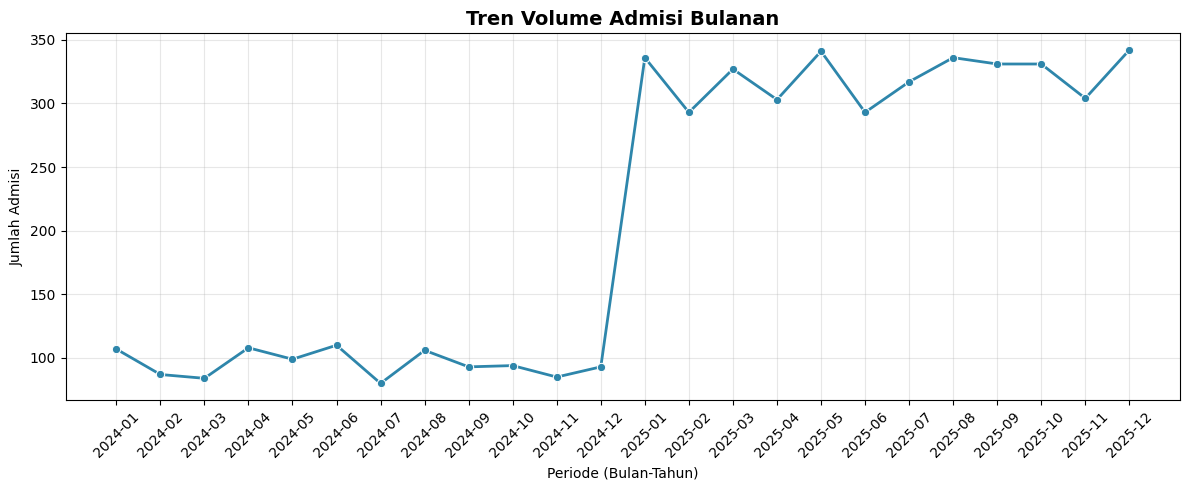

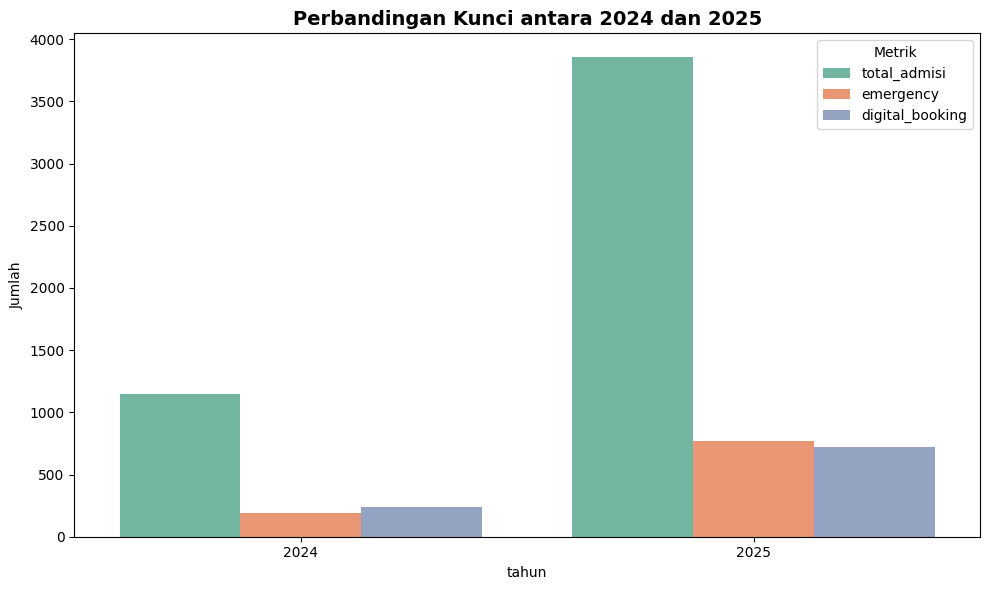

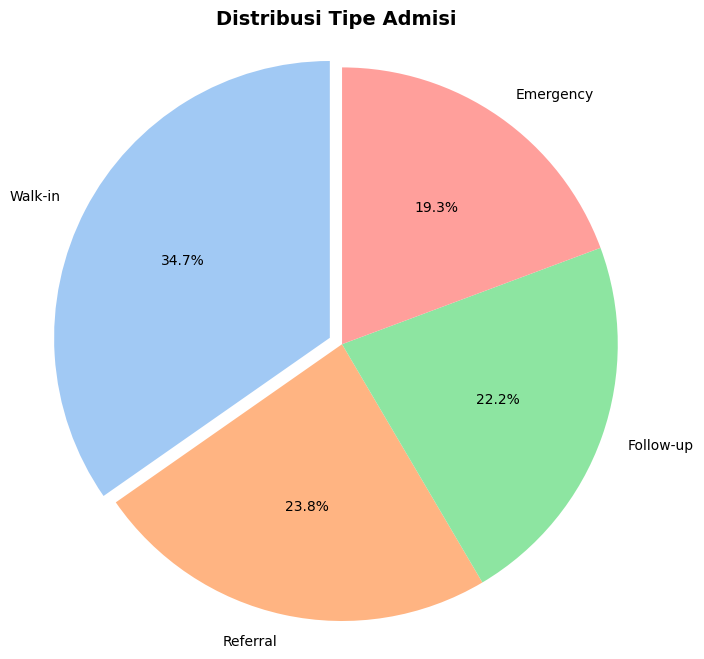

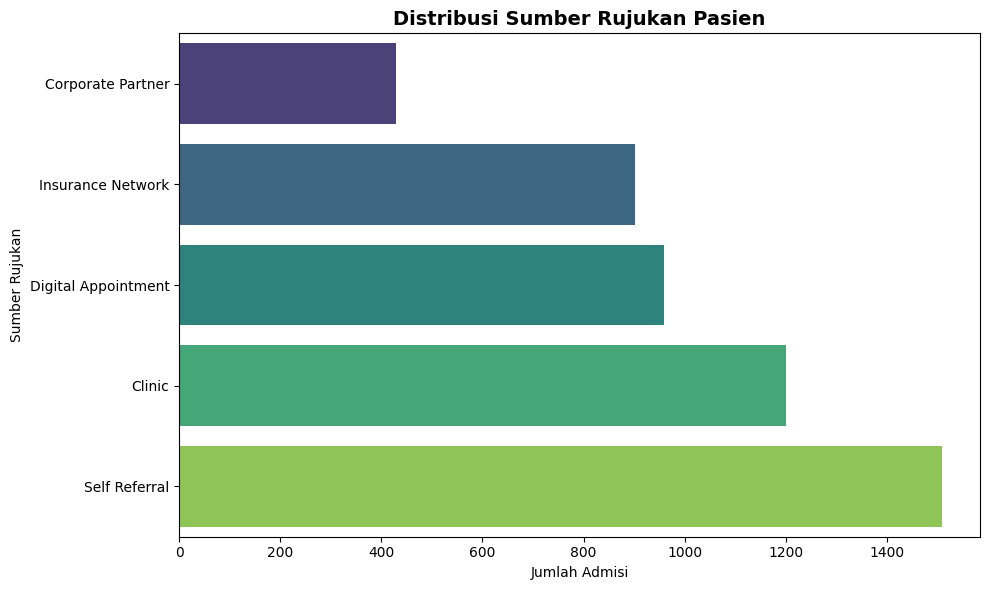

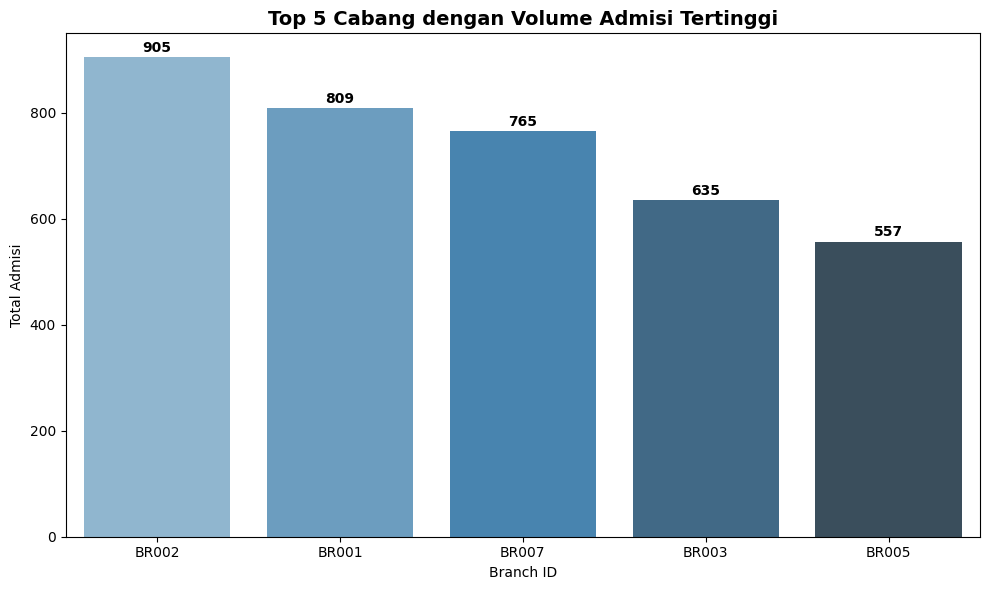

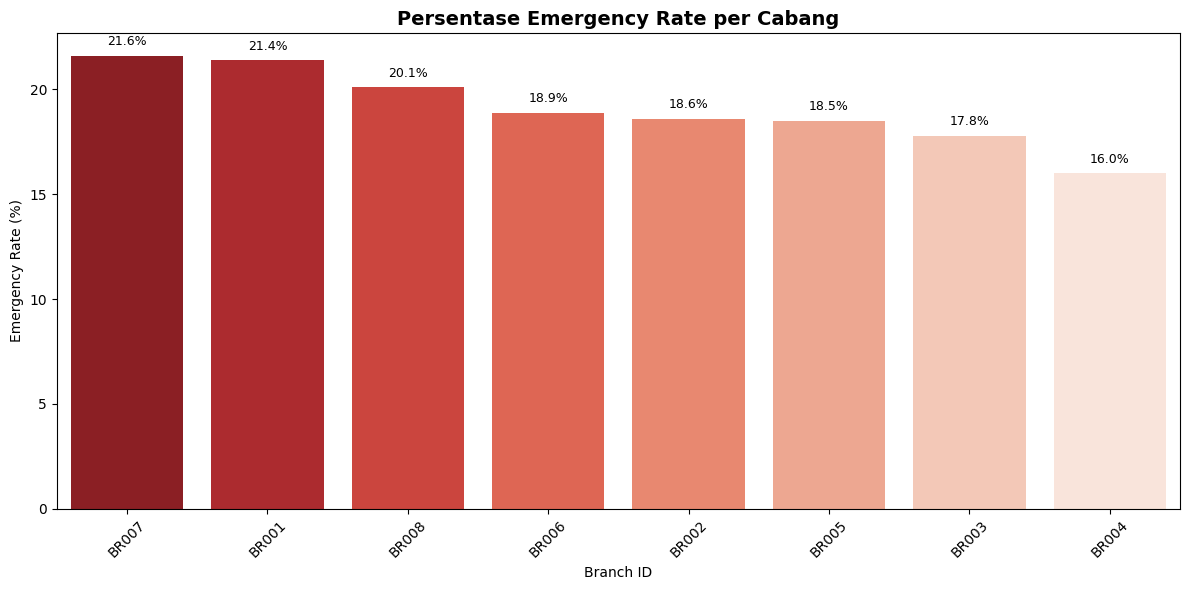

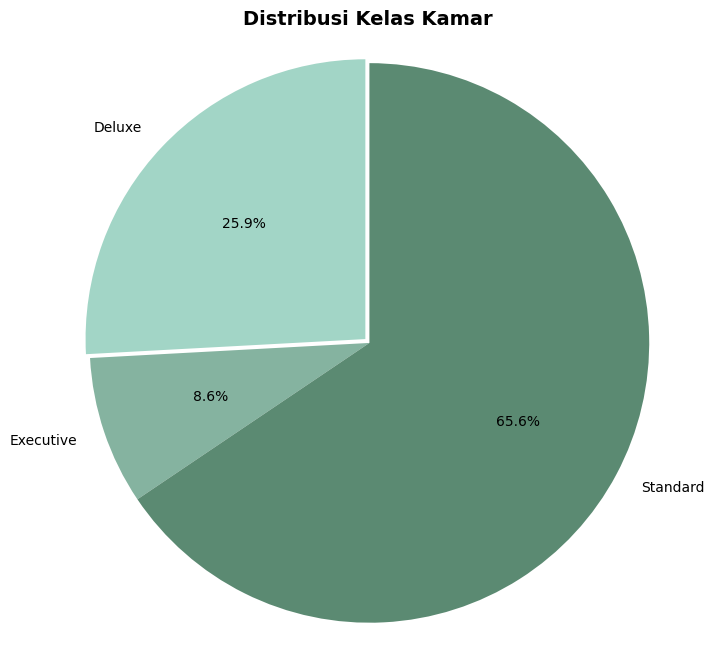

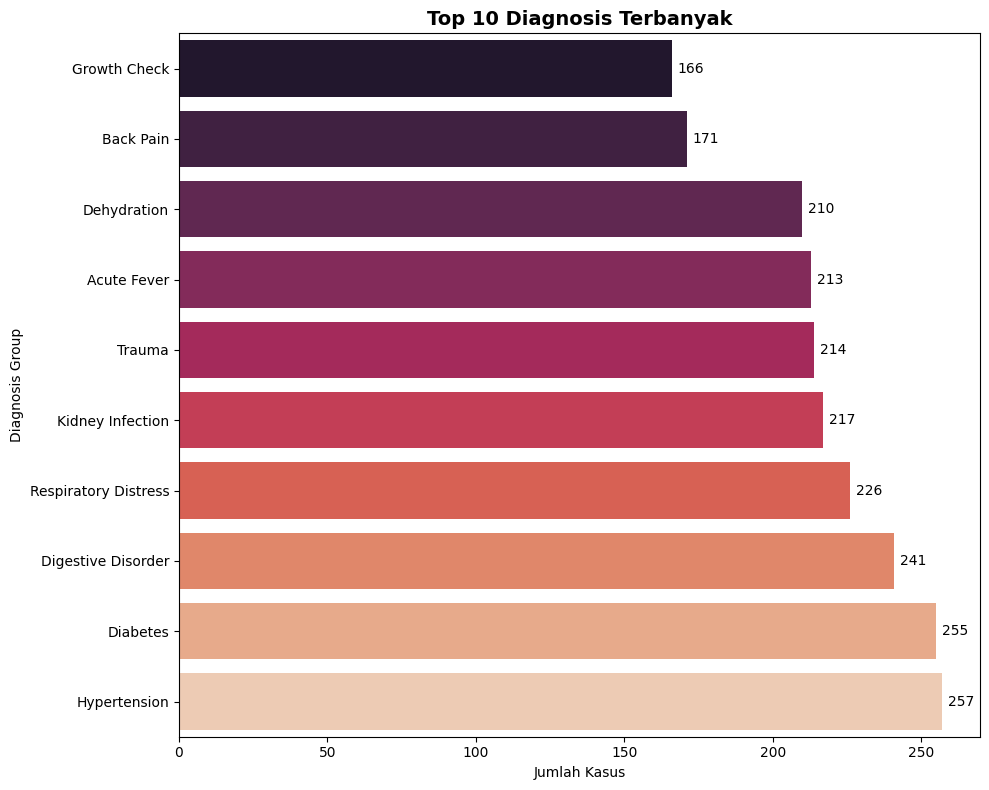

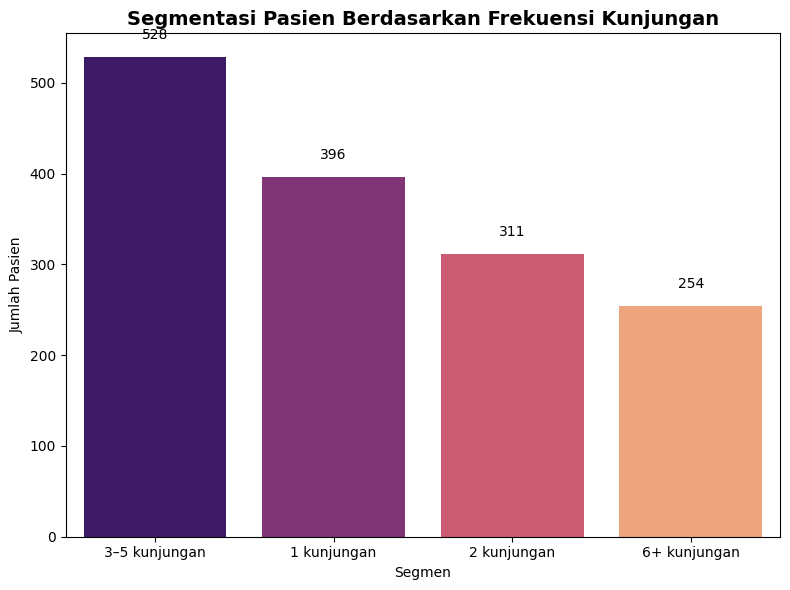

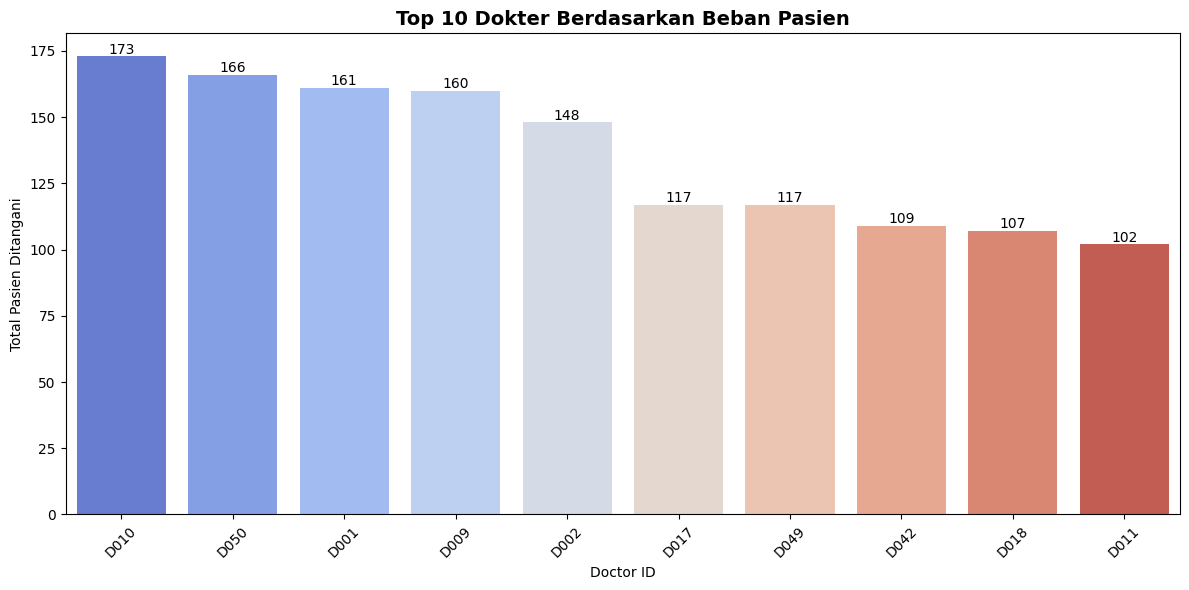

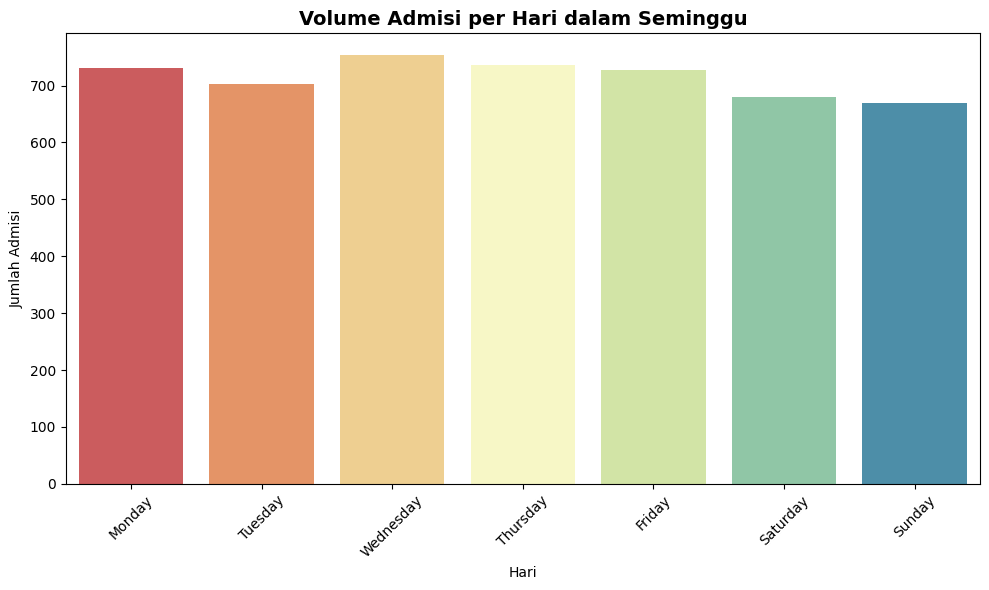

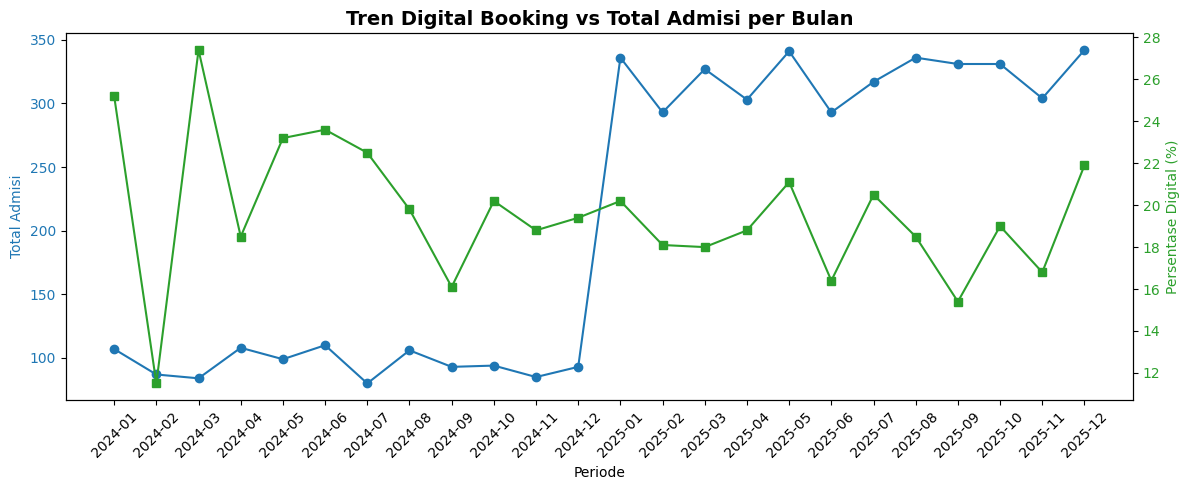

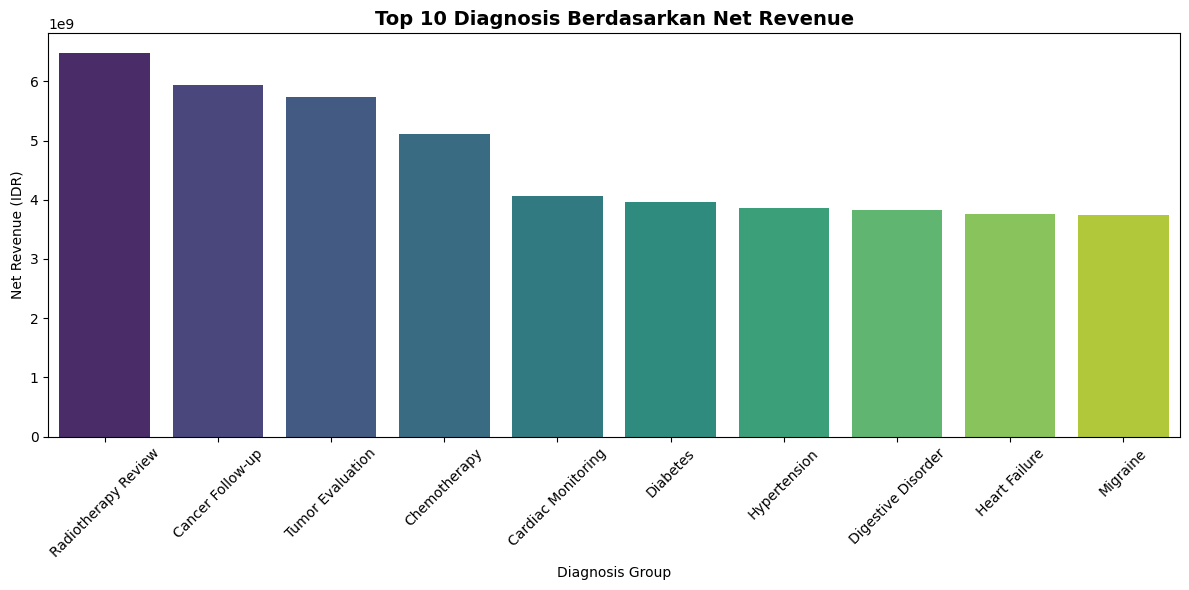

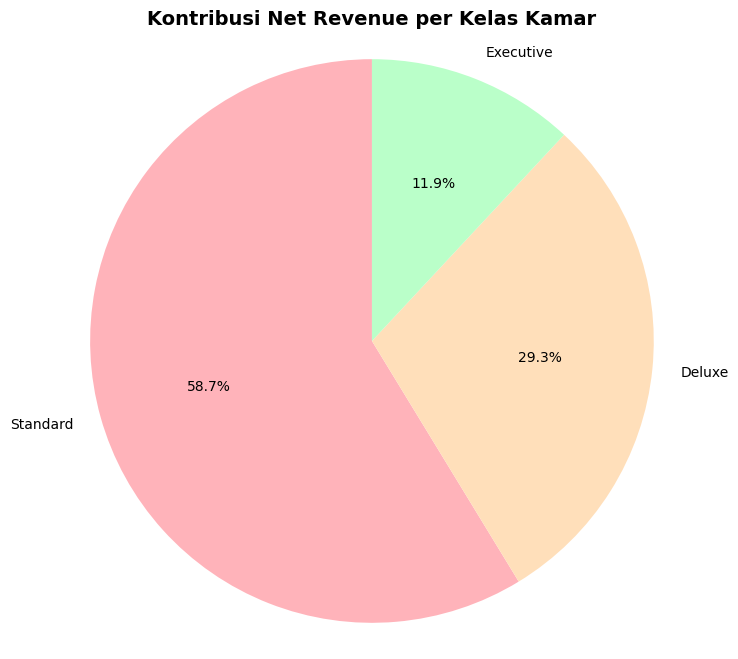


✅ Semua visualisasi telah ditampilkan.


In [11]:
# ============================================================
# VISUALISASI DATA HOSPITAL BUSINESS ANALYSIS
# ============================================================

# --- 1. KPI Overview (Teks saja, tidak divisualisasikan) ---
print("\n📊 KPI Overview sudah tercetak di atas.")

# --- 2. Tren Volume Admisi Bulanan (Line Chart) ---
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_vol, x='periode', y='total_admisi', marker='o', linewidth=2, color='#2E86AB')
plt.title('Tren Volume Admisi Bulanan', fontsize=14, fontweight='bold')
plt.xlabel('Periode (Bulan-Tahun)')
plt.ylabel('Jumlah Admisi')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. Perbandingan 2024 vs 2025 (Bar Chart) ---
yearly_comp_melted = yearly_comp.melt(id_vars='tahun', value_vars=['total_admisi', 'emergency', 'digital_booking'],
                                      var_name='metric', value_name='jumlah')
plt.figure(figsize=(10,6))
sns.barplot(data=yearly_comp_melted, x='tahun', y='jumlah', hue='metric', palette='Set2')
plt.title('Perbandingan Kunci antara 2024 dan 2025', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah')
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

# --- 4. Distribusi Tipe Admisi (Pie Chart) ---
plt.figure(figsize=(8,8))
plt.pie(admission_type_dist['total'], labels=admission_type_dist['admission_type'], autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('pastel'), explode=(0.05,0,0,0))
plt.title('Distribusi Tipe Admisi', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# --- 5. Distribusi Sumber Rujukan (Horizontal Bar Chart) ---
referral_dist_sorted = referral_dist.sort_values('total', ascending=True)
plt.figure(figsize=(10,6))
sns.barplot(data=referral_dist_sorted, y='referral_source', x='total', palette='viridis')
plt.title('Distribusi Sumber Rujukan Pasien', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Admisi')
plt.ylabel('Sumber Rujukan')
plt.tight_layout()
plt.show()

# --- 6. Performa Cabang (Top 5 berdasarkan total admisi) ---
top5_branch = branch_perf.head(5)
plt.figure(figsize=(10,6))
sns.barplot(data=top5_branch, x='branch_id', y='total_admisi', palette='Blues_d')
plt.title('Top 5 Cabang dengan Volume Admisi Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Branch ID')
plt.ylabel('Total Admisi')
for i, v in enumerate(top5_branch['total_admisi']):
    plt.text(i, v+10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# --- 7. Emergency Rate per Cabang (Bar Chart) ---
plt.figure(figsize=(12,6))
sns.barplot(data=branch_perf.sort_values('emergency_rate_pct', ascending=False),
            x='branch_id', y='emergency_rate_pct', palette='Reds_r')
plt.title('Persentase Emergency Rate per Cabang', fontsize=14, fontweight='bold')
plt.xlabel('Branch ID')
plt.ylabel('Emergency Rate (%)')
plt.xticks(rotation=45)
for i, v in enumerate(branch_perf.sort_values('emergency_rate_pct', ascending=False)['emergency_rate_pct']):
    plt.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- 8. Distribusi Kelas Kamar (Pie Chart) ---
plt.figure(figsize=(8,8))
plt.pie(room_class_dist['total'], labels=room_class_dist['room_class'], autopct='%1.1f%%',
        startangle=90, colors=['#A2D5C6', '#85B3A0', '#5B8A72'], explode=(0.02,0,0))
plt.title('Distribusi Kelas Kamar', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# --- 9. Top 10 Diagnosis (Horizontal Bar Chart) ---
diag_top_sorted = diag_top.sort_values('total', ascending=True)
plt.figure(figsize=(10,8))
sns.barplot(data=diag_top_sorted, y='diagnosis_group', x='total', palette='rocket')
plt.title('Top 10 Diagnosis Terbanyak', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kasus')
plt.ylabel('Diagnosis Group')
for i, v in enumerate(diag_top_sorted['total']):
    plt.text(v+2, i, str(v), va='center')
plt.tight_layout()
plt.show()

# --- 10. Segmentasi Frekuensi Kunjungan Pasien (Bar Chart) ---
segmen_dist_sorted = segmen_dist.sort_values('jumlah_pasien', ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(data=segmen_dist_sorted, x='segmen', y='jumlah_pasien', palette='magma')
plt.title('Segmentasi Pasien Berdasarkan Frekuensi Kunjungan', fontsize=14, fontweight='bold')
plt.xlabel('Segmen')
plt.ylabel('Jumlah Pasien')
for i, v in enumerate(segmen_dist_sorted['jumlah_pasien']):
    plt.text(i, v+20, str(v), ha='center')
plt.tight_layout()
plt.show()

# --- 11. Workload Dokter (Top 10 Dokter dengan Total Pasien Terbanyak) ---
top10_doctor = workload.head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10_doctor, x='doctor_id', y='total_pasien', palette='coolwarm')
plt.title('Top 10 Dokter Berdasarkan Beban Pasien', fontsize=14, fontweight='bold')
plt.xlabel('Doctor ID')
plt.ylabel('Total Pasien Ditangani')
plt.xticks(rotation=45)
for i, v in enumerate(top10_doctor['total_pasien']):
    plt.text(i, v+1, str(v), ha='center')
plt.tight_layout()
plt.show()

# --- 12. Volume Admisi per Hari dalam Seminggu (Bar Chart) ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_vol['hari'] = pd.Categorical(day_vol['hari'], categories=day_order, ordered=True)
day_vol_sorted = day_vol.sort_values('hari')
plt.figure(figsize=(10,6))
sns.barplot(data=day_vol_sorted, x='hari', y='total_admisi', palette='Spectral')
plt.title('Volume Admisi per Hari dalam Seminggu', fontsize=14, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Jumlah Admisi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 13. Tren Digital Booking per Bulan (Line + Bar) ---
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.set_xlabel('Periode')
ax1.set_ylabel('Total Admisi', color='tab:blue')
ax1.plot(digital_trend['periode'], digital_trend['total_admisi'], marker='o', color='tab:blue', label='Total Admisi')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticklabels(digital_trend['periode'], rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Persentase Digital (%)', color='tab:green')
ax2.plot(digital_trend['periode'], digital_trend['digital_pct'], marker='s', color='tab:green', label='Digital %')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Tren Digital Booking vs Total Admisi per Bulan', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# --- 14. Revenue per Diagnosis (Top 10) ---
top10_diag_rev = diag_rev.head(10).sort_values('net_revenue', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(data=top10_diag_rev, x='diagnosis_group', y='net_revenue', palette='viridis')
plt.title('Top 10 Diagnosis Berdasarkan Net Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis Group')
plt.ylabel('Net Revenue (IDR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 15. Kontribusi Revenue per Kelas Kamar (Pie Chart) ---
plt.figure(figsize=(8,8))
plt.pie(class_rev['net_revenue'], labels=class_rev['room_class'], autopct='%1.1f%%',
        startangle=90, colors=['#FFB3BA', '#FFDFBA', '#BAFFC9'])
plt.title('Kontribusi Net Revenue per Kelas Kamar', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

print("\n✅ Semua visualisasi telah ditampilkan.")